In [253]:
################################################################################
# Author 1:      Lukas Umfahrer
# MatNr 1:       12337160
# Author 2:      Firstname Lastname
# MatNr 2:       01234567
# Author 3:      Firstname Lastname
# MatNr 3:       01234567
# File:          assignment2.ipynb
# Description: ... short description of the file ...
# Comments:    ... comments for the tutors ...
#              ... can be multiline ...
################################################################################


<center>
    <h1>Assignment 2</h1>
</center>

#### Imports

In [254]:
import pandas as pa
import matplotlib.pyplot as plt
import plotly as pl
import numpy as np
import pycountry as py
import pycountry_convert as pyco

## Part 1: Data Analysis & Visualization Code - Required Plots

### Line plots: Visualize data over time (4P)

In [255]:
data = pa.read_csv("OECD.ELS.HD,DSD_HEALTH_LVNG@DF_HEALTH_LVNG,+all.csv", delimiter = ",")   # reading data

In [256]:
def plot_alcohol_consumption(dataset: str, 
                             plot_title: str, 
                             x_label: str, 
                             y_label: str) -> None:
      
    figure, axis = plt.subplots(figsize=(10,7))
def plot_alcohol_consumption(dataset: str, 
                             plot_title: str, 
                             x_label: str, 
                             y_label: str) -> None:
      
    figure, axis = plt.subplots(figsize=(10,7))

    # using only alcohol consumption data
    data_alc = dataset[dataset["MEASURE"]=="AC"]

    # filtering data from AUT, DEU, USA and CAN
    data_aut = data_alc[data_alc["REF_AREA"]=="AUT"]   
    data_deu = data_alc[data_alc["REF_AREA"]=="DEU"]   
    data_usa = data_alc[data_alc["REF_AREA"]=="USA"]   
    data_can = data_alc[data_alc["REF_AREA"]=="CAN"]


    # calculating mean per year
    data_aut_mean = data_aut.groupby("TIME_PERIOD")["OBS_VALUE"].mean()     
    data_deu_mean = data_deu.groupby("TIME_PERIOD")["OBS_VALUE"].mean() 
    data_usa_mean = data_usa.groupby("TIME_PERIOD")["OBS_VALUE"].mean() 
    data_can_mean = data_can.groupby("TIME_PERIOD")["OBS_VALUE"].mean() 

    # AUT plot
    ys_aut= data_aut_mean.values   # value
    xs_aut = data_aut_mean.index    # year

    axis.plot(xs_aut, ys_aut,
            marker="o",
            markersize="3",
            markeredgecolor="blue",
            label="Austria")
    
    # DEU plot
    ys_deu= data_deu_mean.values   # value
    xs_deu = data_deu_mean.index    # year

    axis.plot(xs_deu, ys_deu,
            marker="o",
            markersize="3",
            markeredgecolor="orange",
            label="Germany")
    
    # USA plot
    ys_usa = data_usa_mean.values   # value
    xs_usa = data_usa_mean.index    # year

    axis.plot(xs_usa, ys_usa,
            marker="o",
            markersize="3",
            markeredgecolor="green",
            label="USA")
    
    # CAN plot
    ys_can= data_can_mean.values   # value
    xs_can = data_can_mean.index    # year
    axis.plot(xs_usa, ys_usa,
            marker="o",
            markersize="3",
            markeredgecolor="green",
            label="USA")
    
    # CAN plot
    ys_can= data_can_mean.values   # value
    xs_can = data_can_mean.index    # year

    axis.plot(xs_can, ys_can,
            marker="o",
            markersize="3",
            markeredgecolor="red",
            label="Canada")

    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.legend()
    plt.title(plot_title)
    plt.grid(True)


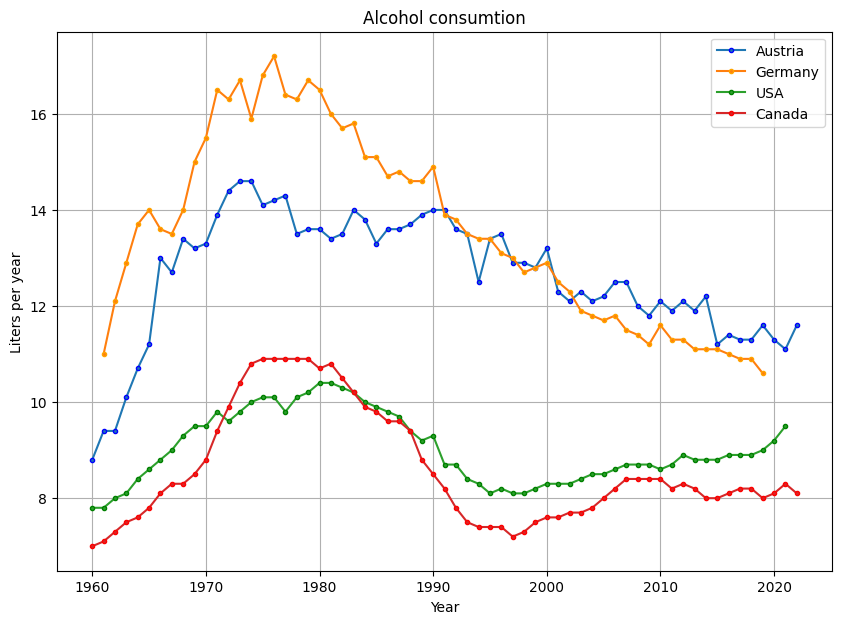

In [257]:
plot_alcohol_consumption(data,
                'Alcohol consumtion',
                'Year',
                'Liters per year') 

### Bar charts: Compare data from different countries (4P)

In [258]:
def plot_overweight(dataset: str, 
                    plot_title: str, 
                    x_label: str, 
                    y_label: str) -> None:
    
   
    # using only data from following countries
    countries = ["AUT", "DEU", "ITA", "USA", "CAN", "POL", "HUN", "FRA", "GBR"]
    data_country = dataset[dataset["REF_AREA"].isin(countries)]

    # filtering sex (in dataset= M, F, _T)
    data_country_sex = data_country[data_country["SEX"].isin(["M", "F"])]

    # calculating mean gouped by countries and sex
    data_mean = data_country_sex.groupby(["REF_AREA", "SEX"])["OBS_VALUE"].mean().unstack()

    # plot
    ax = data_mean.plot(kind="bar", figsize=(10, 6), color=["pink", "blue"])
    

    plt.ylim(0, 100)
    plt.title(plot_title)
    plt.grid(True)
    plt.legend(title="SEX")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

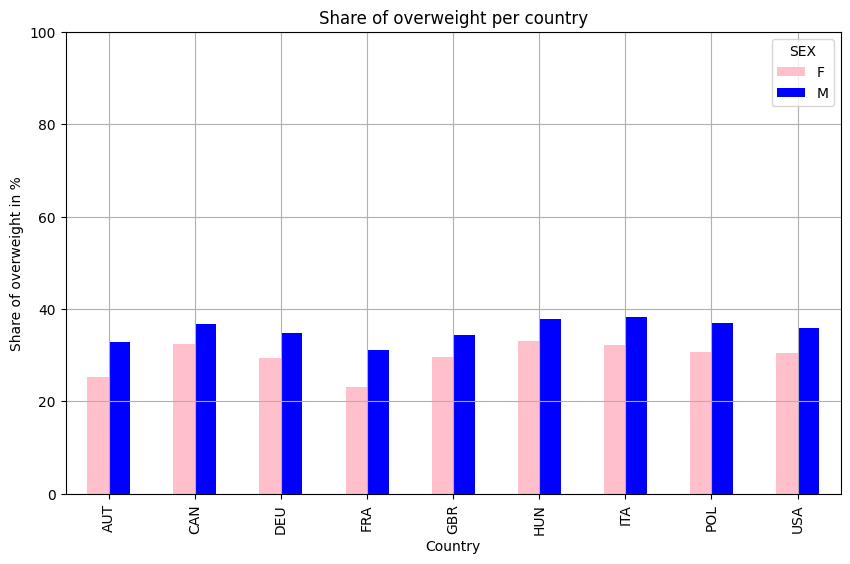

In [259]:
plot_overweight(data, 
                "Share of overweight per country",
                "Country",
                "Share of overweight in %",)

### Scatter plots: Visualize the relationship between different variables (7P)